In [8]:
# Importing Libraries:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='seaborn')
warnings.simplefilter("ignore", UserWarning)

import matplotlib.pyplot as plt
import zipfile
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima



In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Loading Cleaned Dataset:
df = pd.read_csv('/content/drive/My Drive/EV_CleanedDataset.csv')
# Look at the Dataset:
df.head()


,account,premise_desc_code,size,customer_type,heating_type,heating_group,last_yr_kwh_usage,last_yr_avg_kwh_usage,geo_area_code,city,...,children_desc_code,can_afford_ev,est_rate_code,recently_bought_home,est_social_media_income,est_alternative_financing,EVFlag,energy_efficiency_index,affordability_index,sustainability_interest_index
0,1,DU,SMALL,MULTI FAMILY- ELECTRIC,ELECTRIC BASEBOARD,Electric,16279.0,1281.0,0.0,0.0,...,0.0,0.68,0.0,0.0,0.0,0.86,0.0,10.048765,0.00,0.0
1,2,SF,MED,SINGLE FAMILY - OTHER HEAT,GAS FURNACE,Non-Electric,48531.0,6036.0,1.0,1.0,...,1.0,0.76,0.0,0.0,1.0,0.87,0.0,12.711105,0.24,0.0
2,3,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,9801.0,846.0,2.0,2.0,...,0.0,0.96,0.0,0.0,0.0,0.82,0.0,3.296670,0.08,1.0
3,4,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,9801.0,846.0,2.0,2.0,...,0.0,0.96,0.0,0.0,0.0,0.82,0.0,3.296670,0.08,1.0
4,5,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,7408.0,602.0,2.0,2.0,...,0.0,0.96,0.0,0.0,0.0,0.82,0.0,2.491759,0.08,1.0


In [11]:
df.shape

(393854, 69)

In [12]:
# Extract object columns again:
nonnumeric_columns = df.select_dtypes('object')
nonnumeric_columns.columns

Index(['premise_desc_code', 'size', 'customer_type', 'heating_type',
       'heating_group', 'move_in_date', 'home_bought_date'],
      dtype='object')

In [13]:
# Define the columns to encode
one_hot_columns = ['premise_desc_code', 'customer_type', 'heating_type', 'heating_group']
ordinal_columns = ['size'] # Will Encoding
date_columns = ['move_in_date', 'home_bought_date']

# 1. One-Hot Encoding for Categorical Columns
df_one_hot = pd.get_dummies(df, columns=one_hot_columns, drop_first=True)

# 2. Ordinal Encoding for Ordered Categories (like 'size')
size_mapping = {'SMALL': 1, 'MED': 2, 'LARGE': 3, 'XL': 4, 'Unassigned': 0}
df_one_hot['size'] = df_one_hot['size'].map(size_mapping)

# 3. Handle Date Columns by Extracting Features (e.g., days since move-in/home bought)

# Convert move_in_date and home_bought_date to datetime
df_one_hot['move_in_date'] = pd.to_datetime(df_one_hot['move_in_date'], errors='coerce')
df_one_hot['home_bought_date'] = pd.to_datetime(df_one_hot['home_bought_date'], errors='coerce')

# Calculate 'days since' for move_in_date and home_bought_date
df_one_hot['days_since_move_in'] = (pd.to_datetime('today') - df_one_hot['move_in_date']).dt.days
df_one_hot['days_since_home_bought'] = (pd.to_datetime('today') - df_one_hot['home_bought_date']).dt.days

# Extract year, month, and day from the dates
df_one_hot['move_in_year'] = df_one_hot['move_in_date'].dt.year
df_one_hot['move_in_month'] = df_one_hot['move_in_date'].dt.month
df_one_hot['move_in_day'] = df_one_hot['move_in_date'].dt.day

df_one_hot['home_bought_year'] = df_one_hot['home_bought_date'].dt.year
df_one_hot['home_bought_month'] = df_one_hot['home_bought_date'].dt.month
df_one_hot['home_bought_day'] = df_one_hot['home_bought_date'].dt.day

# Drop the original 'move_in_date' and 'home_bought_date' columns if you don't need them
df_one_hot.drop(columns=['move_in_date', 'home_bought_date'], inplace=True)

In [14]:
# EV Distribution:
df['EVFlag'].value_counts()

,count
EVFlag,
0.0,353803
1.0,40051


#### Estimate EV OwnerShip Growth:

Formula:

Final EV Count=Initial EV Count×(1+Growth Rate)^Time

- Initial EV count = 10,000.
- Growth rate = 40% .
- Time = 4 years ( currently at the 4th year).

Using the formula:

- Final EV Count = 10,000 × (1 + 0.4)^4 = 38,416

- Initial EV count: 10,000 EVs
- Year 1: 10,000 * (1 + 0.4)^1 = 14,000 EVs
- Year 2: 10,000 * (1 + 0.4)^2 = 19,600 EVs
- Year 3: 10,000 * (1 + 0.4)^3 = 27,440 EVs
- Year 4: 10,000 * (1 + 0.4)^4 = 38,416 EVs

If we want the formula to perfectly match our dataset where Year 4 has 40,051 EVs, we should use the adjusted initial value of 10,422 instead of 10,000. So:

- Initial EV count: 10,422 EVs
- Year 1: 10,422 * (1 + 0.4)^1 = 14,591 EVs
- Year 2: 10,422 * (1 + 0.4)^2 = 20,427 EVs
- Year 3: 10,422 * (1 + 0.4)^3 = 28,598 EVs
- Year 4: 10,422 * (1 + 0.4)^4 = 40,051 EVs (Matches with dataset)

In [15]:
# Add a 'Year' column representing the snapshot year
df["Year"] = 4

ev_counts = {
    1: int(10_422 * (1.4) ** 1),  # 14,591
    2: int(10_422 * (1.4) ** 2),  # 20,427
    3: int(10_422 * (1.4) ** 3),  # 28,598
    4: int(10_422 * (1.4) ** 4)   # 40,051
}

# Get the current EV owners
ev_owners = df[df["EVFlag"] == 1]

# Create synthetic data for previous years
synthetic_dfs = []

# Generate for Years 1, 2, and 3
for year in range(1, 4):
    num_evs_needed = ev_counts[year]# Calculate how many EVs should exist in this year
    sampled_ev_owners = ev_owners.sample(n=num_evs_needed, replace=True, random_state=42)     # Randomly sample a subset of EV owners for this year


    # Update their year
    sampled_ev_owners = sampled_ev_owners.copy()
    sampled_ev_owners["Year"] = year

    # Append to synthetic data list
    synthetic_dfs.append(sampled_ev_owners)

# Combine all years together
df_time_series = pd.concat([df] + synthetic_dfs, ignore_index=True)

# Sort data by account and year
df_time_series = df_time_series.sort_values(by=["account", "Year"]).reset_index(drop=True)

# Save the new dataset
df_time_series.to_csv("ev_time_series_data.csv", index=False)



In [16]:
# Look at the dataset:
df_time_series .head()

,account,premise_desc_code,size,customer_type,heating_type,heating_group,last_yr_kwh_usage,last_yr_avg_kwh_usage,geo_area_code,city,...,can_afford_ev,est_rate_code,recently_bought_home,est_social_media_income,est_alternative_financing,EVFlag,energy_efficiency_index,affordability_index,sustainability_interest_index,Year
0,1,DU,SMALL,MULTI FAMILY- ELECTRIC,ELECTRIC BASEBOARD,Electric,16279.0,1281.0,0.0,0.0,...,0.68,0.0,0.0,0.0,0.86,0.0,10.048765,0.00,0.0,4
1,2,SF,MED,SINGLE FAMILY - OTHER HEAT,GAS FURNACE,Non-Electric,48531.0,6036.0,1.0,1.0,...,0.76,0.0,0.0,1.0,0.87,0.0,12.711105,0.24,0.0,4
2,3,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,9801.0,846.0,2.0,2.0,...,0.96,0.0,0.0,0.0,0.82,0.0,3.296670,0.08,1.0,4
3,4,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,9801.0,846.0,2.0,2.0,...,0.96,0.0,0.0,0.0,0.82,0.0,3.296670,0.08,1.0,4
4,5,SF,MED,SINGLE FAMILY - ELECTRIC,ELECTRIC HEAT PUMP,Electric,7408.0,602.0,2.0,2.0,...,0.96,0.0,0.0,0.0,0.82,0.0,2.491759,0.08,1.0,4


In [17]:
# Shape
df_time_series.shape

(457468, 70)

In [18]:
# Load the dataset
df = pd.read_csv("ev_time_series_data.csv")

# Aggregate EV ownership count per year
ev_trend = df[df["EVFlag"] == 1].groupby("Year").size().reset_index(name="EV_Count")

print(ev_trend)


   Year  EV_Count
0     1     14590
1     2     20427
2     3     28597
3     4     40051


In [21]:
# Fit ARIMA model
# Aggregate EV count by year
df_yearly = df_time_series.groupby("Year")["EVFlag"].sum().reset_index()
model = ARIMA(df_yearly["EVFlag"], order=(2,1,2))  # p = 2 (The model uses 2 past years of EV counts to predict the next).
                                                   # d = 1 (The model looks at the change between consecutive years to remove trends and stabilize the series).
                                                   # q = 2 (The model accounts for errors from the last 2 years. Helps capture short-term fluctuations.).


model_fit = model.fit()

# Forecast next 3 years(Year 5, 6, 7)
forecast = model_fit.forecast(steps=3)
print(forecast)


4    48164.309798
5    56637.762221
6    64820.848174
Name: predicted_mean, dtype: float64


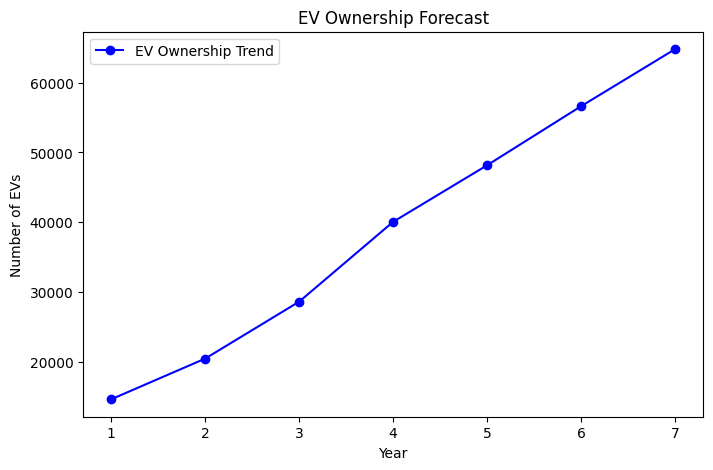

   Year      EV_Count
4     5  48164.309798
5     6  56637.762221
6     7  64820.848174


In [22]:
# Add predictions to dataframe
future_years = [5, 6, 7]
future_forecast = pd.DataFrame({"Year": future_years, "EV_Count": forecast})

# Combine past and future data
ev_forecast = pd.concat([ev_trend, future_forecast], ignore_index=True)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(ev_forecast["Year"], ev_forecast["EV_Count"], marker="o", linestyle="-", color="b", label="EV Ownership Trend")
plt.xlabel("Year")
plt.ylabel("Number of EVs")
plt.title("EV Ownership Forecast")
plt.legend()
plt.show()

# Print forecasted values
print(future_forecast)


In [23]:
# Find best (p, d, q) values automatically
# Fit an ARIMA model (p, d, q) where:
# p = number of past observations to consider (autoregression)
# d = differencing (to remove trends)
# q = moving average component

auto_model = auto_arima(df_yearly["EVFlag"], seasonal=False, trace=True)
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=91.795, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=95.163, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=90.391, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.170 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    4
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -43.196
Date:                Tue, 18 Feb 2025   AIC                             90.391
Time:                        18:53:58   BIC                             89.164
Sample:                             0   HQIC                            87.698
                                  - 4                                         
Covariance Ty

In [24]:
# Fit ARIMA model
model = ARIMA(df_yearly["EVFlag"], order=(1,0,0))  # p = 1 (1 past year value is used to predict the next).
                                                   # d = 0 (No differencing needed, data is already stationary).
                                                   # q = 0 (No moving average component, past errors aren't used).


model_fit = model.fit()

# Forecast next 3 years(Year 5, 6, 7)
forecast = model_fit.forecast(steps=3)
print(forecast)


4    34540.976931
5    31178.876839
6    29127.394135
Name: predicted_mean, dtype: float64


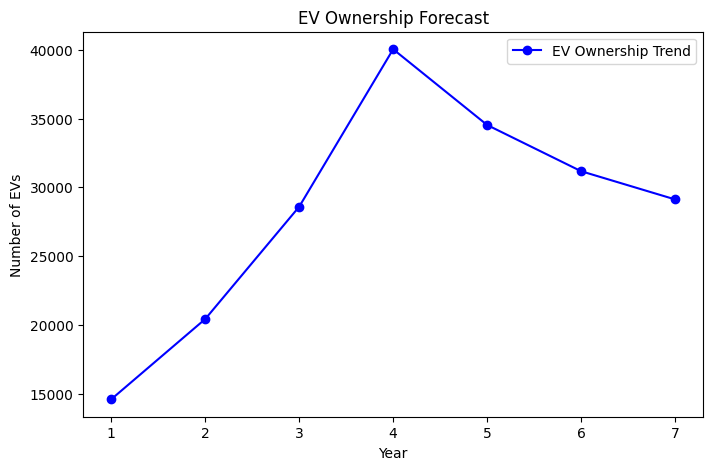

   Year      EV_Count
4     5  34540.976931
5     6  31178.876839
6     7  29127.394135


In [25]:
# Add predictions to dataframe
future_years = [5, 6, 7]
future_forecast = pd.DataFrame({"Year": future_years, "EV_Count": forecast})

# Combine past and future data
ev_forecast = pd.concat([ev_trend, future_forecast], ignore_index=True)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(ev_forecast["Year"], ev_forecast["EV_Count"], marker="o", linestyle="-", color="b", label="EV Ownership Trend")
plt.xlabel("Year")
plt.ylabel("Number of EVs")
plt.title("EV Ownership Forecast")
plt.legend()
plt.show()

# Print forecasted values
print(future_forecast)
